# 5c — Plot Flood Scenarios Accessibility

## Purpose
Visualise the basin-scenario accessibility results computed by script 5b: increased travel times from settlements to emergency services (hospitals, police, fire stations), from industrial areas to border crossings, and from agricultural areas to road borders, ports, and rail terminals. The exposed-edge impact layers are saved to parquet + ArcGIS File Geodatabase + Excel in EPSG:6316.

## Inputs
| File | Description |
|------|-------------|
| `intermediate_results/SRB_flood_statistics_per_Basin_basins_scenario.csv` | Flood statistics per basin (from 5b) |
| `input_files/hybas_eu_lev09_v1c.shp` | HydroBASINS level-9 basin polygons |
| `input_files/base_network_SRB_basins.parquet` | Basin-scenario base road network |
| `accessibility_analysis/{healthcare,police,fire,factory}_criticality_results/save_new_results_SRB_basins.pkl` | Per-basin disruption results per service (from 5b) |
| `accessibility_analysis/allagri_criticality_results/save_new_results_SRB_basins.pkl` | Per-basin agriculture disruption results (from 5b) |

## Outputs
| File | Description |
|------|-------------|
| `figures/basin_water_depths.png` | Mean water depth per basin |
| `figures/hospital_criticality.png` | Increased travel time to hospitals |
| `figures/police_criticality.png` | Increased travel time to police stations |
| `figures/fire_criticality.png` | Increased travel time to fire stations |
| `figures/factory_criticality.png` | Increased travel time from industrial areas to borders |
| `figures/SRB_agri_criticality_avg_3x1.png` | Agriculture: average increased travel time (borders / ports / rail) |
| `figures/SRB_agri_criticality_nearest_3x1.png` | Agriculture: increased travel time to nearest sink |
| `figures/criticality_2x2.png` | Combined 2×2 figure (hospitals, factories, police, fire) |
| `intermediate_results/parquet/local_accessibility/{hospital,factory,police,fire,road,rail,port}_impacts.parquet` | Impact layers (EPSG:6316) |
| `intermediate_results/parquet/local_accessibility/{...}_impacts.xlsx` | Excel attribute tables |
| `intermediate_results/database/local_accessibility/local_accessibility.gdb` | GDB layers for all impact layers |

## Key Processing Steps
1. **Basin water depths** — merge per-basin flood statistics with HydroBASINS geometries; plot depth classes
2. **Base network** — load basin-scenario road network; keep the giant connected component (EPSG:3857)
3. **Service criticality** — per service (hospitals, police, fire, factories): assign each basin's mean positive travel-time delta to its removed edges; keep exposed edges with ≥ 10 min impact; bin into delay classes
4. **Agriculture criticality** — same logic per sink type (road borders, ports, rail terminals) for the average and nearest-sink delta columns
5. **Figures** — single map per service, 3×1 agriculture figures (average and nearest), combined 2×2 figure
6. **Save** — all seven impact layers to parquet + GDB + Excel (EPSG:6316)

<div style="
    border-left: 6px solid #1f6feb;
    padding: 0.7em 1em;
    background: #f0f7ff;
    border-radius: 4px;
    margin: 1em 0;
    font-size: 1.05em;
    color: #0a0a0a;
">
  <strong>📝 Note:</strong> This notebook requires the results computed by script 5b_Run_Flood_Scenarios_Accessibility.py to run
</div>

In [1]:
import sys
import warnings
from pathlib import Path

BASE_DIR = Path.cwd().parent 
sys.path.append(str(BASE_DIR))

from utils.criticality_functions import (
    calculate_agri_criticality,
    calculate_service_criticality,
    load_base_network,
    load_basins,
    plot_agri_criticality_3x1,
    plot_basin_water_depths,
    plot_criticality_2x2,
    plot_service_criticality,
    print_delay_category_counts,
    save_impact_layers,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [2]:
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
accessibility_analysis_path = BASE_DIR / "accessibility_analysis"
parquet_dir = intermediate_results_path / "parquet" / "local_accessibility"
gdb_path = intermediate_results_path / "database" / "local_accessibility" / "local_accessibility.gdb"
output_crs = "EPSG:6316"

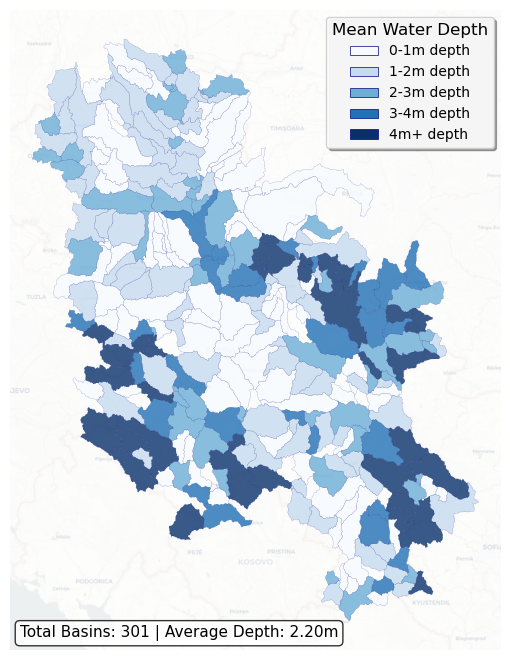

In [3]:
# Basin water depths
basins = load_basins(
    intermediate_results_path / "SRB_flood_statistics_per_Basin_basins_scenario.csv",
    data_path / "hybas_eu_lev09_v1c.shp",
)
plot_basin_water_depths(basins, figure_path)

In [4]:
# Base network (giant connected component, EPSG:3857)
base_network = load_base_network(data_path / "base_network_SRB_basins.parquet")

## Emergency Services and Factories


Delay categories — hospital:
  10-20 min :  18773 ( 26.8%)
  20-30 min :  17384 ( 24.9%)
  30-40 min :  18207 ( 26.0%)
  40-60 min :  14204 ( 20.3%)
  60+ min   :   1358 (  1.9%)
  Total     :  69926
  Mean delay   :   31.2 min
  Median delay :   28.8 min
  Share 20-60 min:  71.2% (49795/69926)


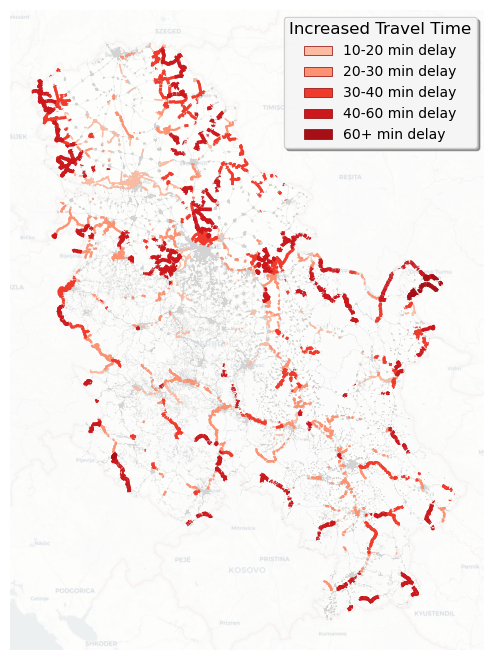

In [5]:
hospital_exposed_edges = calculate_service_criticality(
    accessibility_analysis_path / "healthcare_criticality_results" / "save_new_results_SRB_basins.pkl",
    base_network,
)
print_delay_category_counts(hospital_exposed_edges, "hospital")
plot_service_criticality(hospital_exposed_edges, base_network, figure_path, "hospital_criticality.png")


Delay categories — police:
  10-20 min :  12219 ( 17.4%)
  20-30 min :  14128 ( 20.1%)
  30-40 min :  23746 ( 33.8%)
  40-60 min :  20058 ( 28.5%)
  60+ min   :    185 (  0.3%)
  Total     :  70336
  Mean delay   :   33.0 min
  Median delay :   32.5 min
  Share 20-60 min:  82.4% (57932/70336)


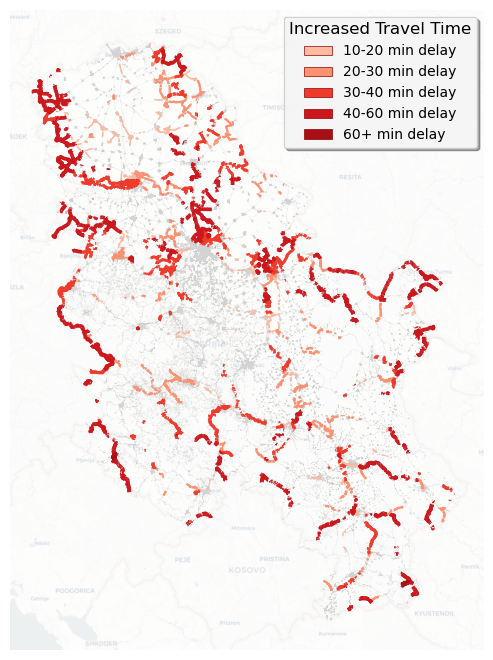

In [6]:
police_exposed_edges = calculate_service_criticality(
    accessibility_analysis_path / "police_criticality_results" / "save_new_results_SRB_basins.pkl",
    base_network,
)
print_delay_category_counts(police_exposed_edges, "police")
plot_service_criticality(police_exposed_edges, base_network, figure_path, "police_criticality.png")


Delay categories — fire station:
  10-20 min :  11744 ( 16.6%)
  20-30 min :  16299 ( 23.0%)
  30-40 min :  21327 ( 30.1%)
  40-60 min :  21359 ( 30.1%)
  60+ min   :    177 (  0.2%)
  Total     :  70906
  Mean delay   :   33.9 min
  Median delay :   35.6 min
  Share 20-60 min:  83.2% (58985/70906)


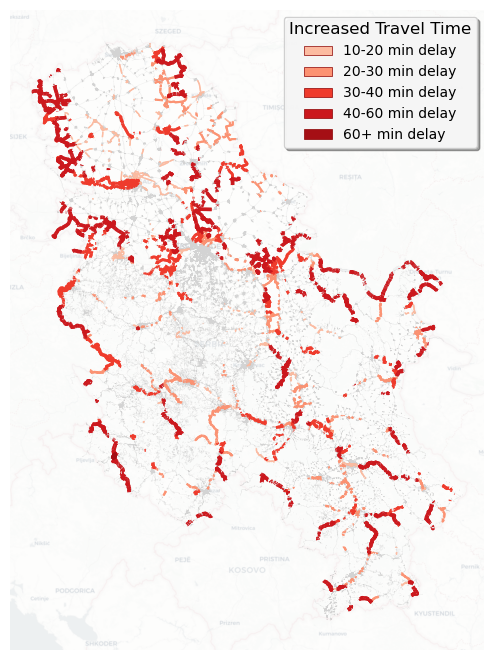

In [7]:
fire_exposed_edges = calculate_service_criticality(
    accessibility_analysis_path / "fire_criticality_results" / "save_new_results_SRB_basins.pkl",
    base_network,
)
print_delay_category_counts(fire_exposed_edges, "fire station")
plot_service_criticality(fire_exposed_edges, base_network, figure_path, "fire_criticality.png")


Delay categories — factory -> border:
  10-20 min :  11270 ( 40.8%)
  20-30 min :   3000 ( 10.9%)
  30-40 min :     88 (  0.3%)
  40-60 min :   4334 ( 15.7%)
  60+ min   :   8904 ( 32.3%)
  Total     :  27596
  Mean delay   :   73.1 min
  Median delay :   28.0 min
  Share 20-60 min:  26.9% (7422/27596)


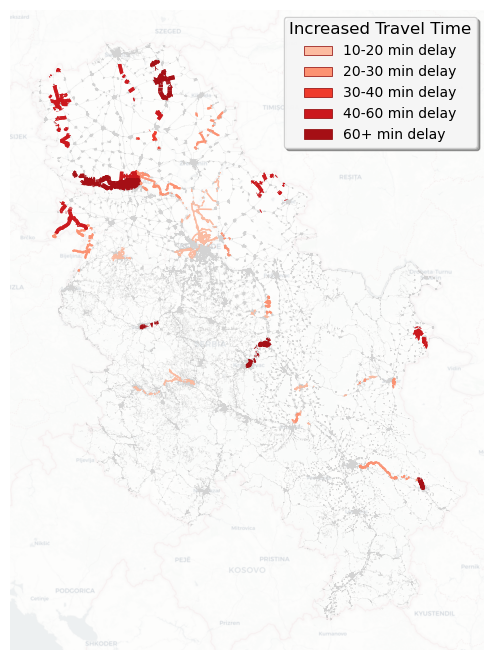

In [8]:
factory_exposed_edges = calculate_service_criticality(
    accessibility_analysis_path / "factory_criticality_results" / "save_new_results_SRB_basins.pkl",
    base_network,
)
print_delay_category_counts(factory_exposed_edges, "factory -> border")
plot_service_criticality(factory_exposed_edges, base_network, figure_path, "factory_criticality.png")

## Agriculture Criticality (Road Borders / Ports / Rail Terminals)

Processing: road...
  62957 edges
Processing: port...
  67726 edges
Processing: rail...
  57766 edges

Delay categories — agriculture road (average sink):
  10-20 min :  19157 ( 30.4%)
  20-30 min :   4659 (  7.4%)
  30-40 min :   7549 ( 12.0%)
  40-60 min :  15195 ( 24.1%)
  60+ min   :  16397 ( 26.0%)
  Total     :  62957
  Mean delay   :   61.4 min
  Median delay :   40.6 min
  Share 20-60 min:  43.5% (27403/62957)

Delay categories — agriculture port (average sink):
  10-20 min :  11884 ( 17.5%)
  20-30 min :   2948 (  4.4%)
  30-40 min :   4085 (  6.0%)
  40-60 min :  10290 ( 15.2%)
  60+ min   :  38519 ( 56.9%)
  Total     :  67726
  Mean delay   :   97.6 min
  Median delay :   68.6 min
  Share 20-60 min:  25.6% (17323/67726)

Delay categories — agriculture rail (average sink):
  10-20 min :  13240 ( 22.9%)
  20-30 min :   7675 ( 13.3%)
  30-40 min :  12846 ( 22.2%)
  40-60 min :   5872 ( 10.2%)
  60+ min   :  18133 ( 31.4%)
  Total     :  57766
  Mean delay   :   77.7 min
  Medi

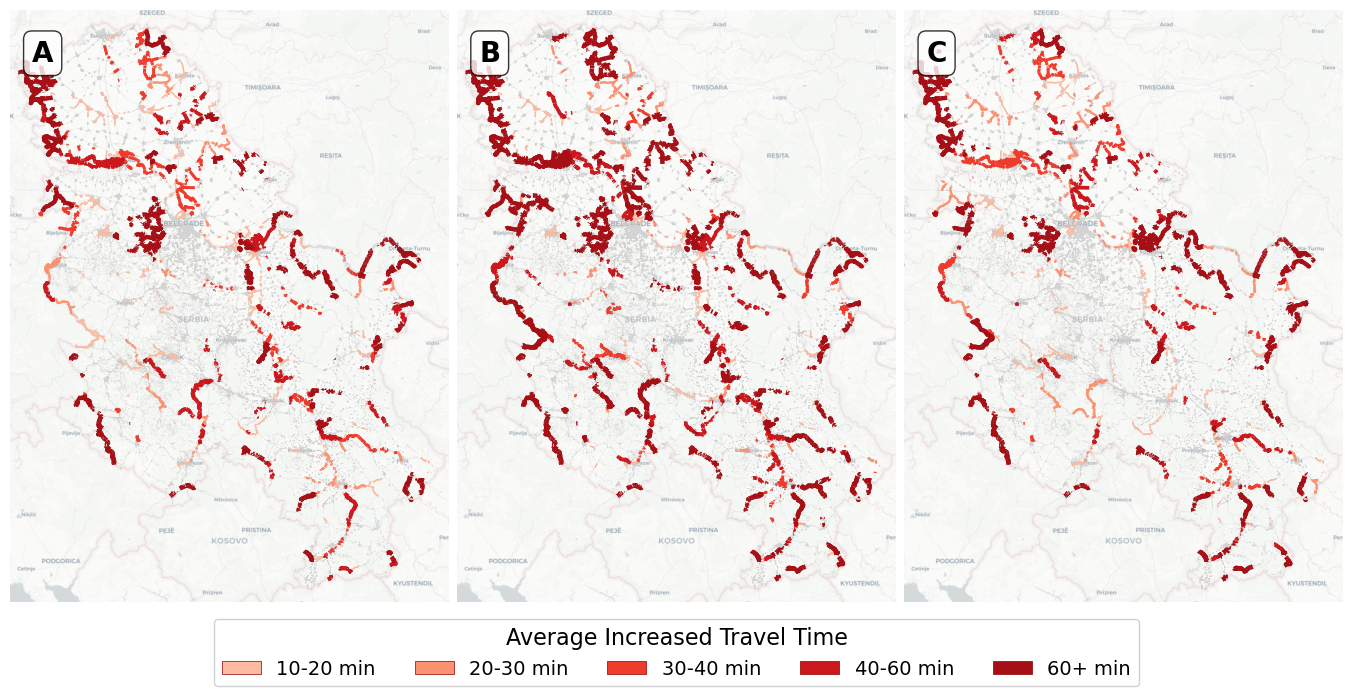

In [9]:
agri_results_path = (
    accessibility_analysis_path / "allagri_criticality_results" / "save_new_results_SRB_basins.pkl"
)

# Average increased travel time over all sinks of each type
agri_avg = calculate_agri_criticality(agri_results_path, base_network, delta_prefix="delta_avg")
for sink_type, edges in agri_avg.items():
    print_delay_category_counts(edges, f"agriculture {sink_type} (average sink)")
plot_agri_criticality_3x1(
    agri_avg, base_network, figure_path,
    file_name="SRB_agri_criticality_avg_3x1.png",
    legend_title="Average Increased Travel Time",
)

Processing: road...
  48604 edges
Processing: port...
  50077 edges
Processing: rail...
  47757 edges

Delay categories — agriculture road (nearest sink):
  10-20 min :  19265 ( 39.6%)
  20-30 min :  22199 ( 45.7%)
  30-40 min :   3558 (  7.3%)
  40-60 min :   2876 (  5.9%)
  60+ min   :    706 (  1.5%)
  Total     :  48604
  Mean delay   :   23.4 min
  Median delay :   22.3 min
  Share 20-60 min:  58.9% (28633/48604)

Delay categories — agriculture port (nearest sink):
  10-20 min :  15597 ( 31.1%)
  20-30 min :  24307 ( 48.5%)
  30-40 min :   4157 (  8.3%)
  40-60 min :   3620 (  7.2%)
  60+ min   :   2396 (  4.8%)
  Total     :  50077
  Mean delay   :   26.3 min
  Median delay :   21.6 min
  Share 20-60 min:  64.1% (32084/50077)

Delay categories — agriculture rail (nearest sink):
  10-20 min :  25721 ( 53.9%)
  20-30 min :  13107 ( 27.4%)
  30-40 min :   1581 (  3.3%)
  40-60 min :   5803 ( 12.2%)
  60+ min   :   1545 (  3.2%)
  Total     :  47757
  Mean delay   :   23.4 min
  Medi

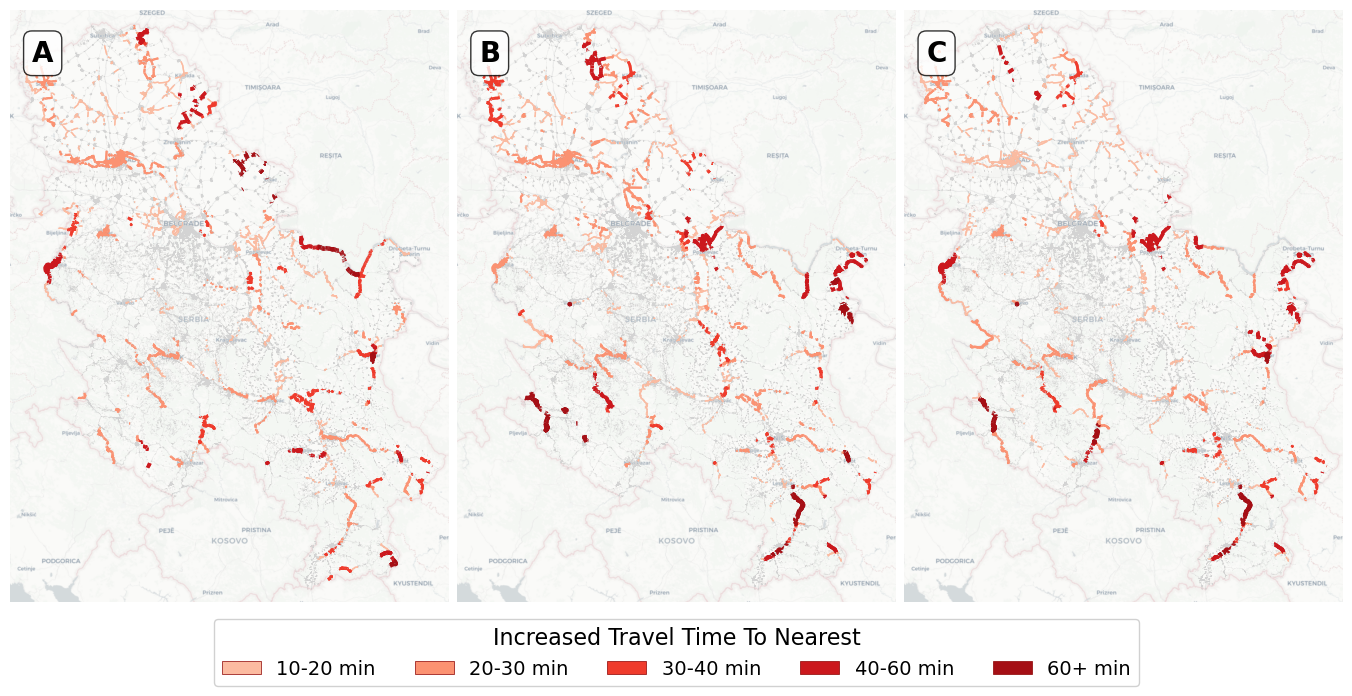

In [10]:
# Increased travel time to the nearest sink of each type
agri_nearest = calculate_agri_criticality(agri_results_path, base_network, delta_prefix="delta_nearest")
for sink_type, edges in agri_nearest.items():
    print_delay_category_counts(edges, f"agriculture {sink_type} (nearest sink)")
plot_agri_criticality_3x1(
    agri_nearest, base_network, figure_path,
    file_name="SRB_agri_criticality_nearest_3x1.png",
    legend_title="Increased Travel Time To Nearest",
)

## Combined Criticality Figure

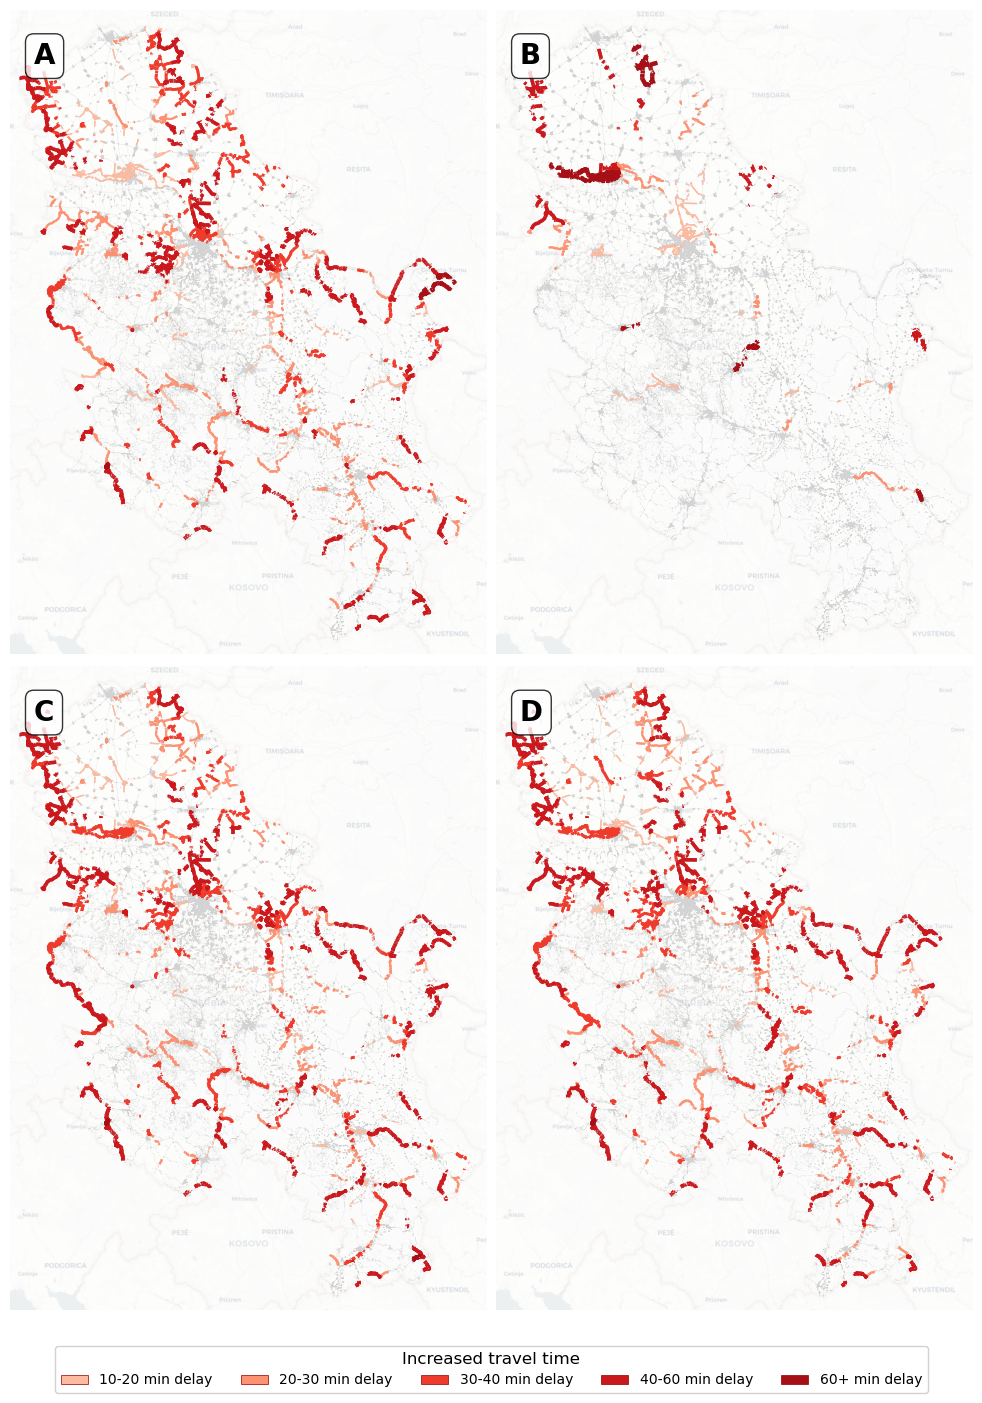

In [11]:
plot_criticality_2x2(
    hospital_exposed_edges, factory_exposed_edges,
    police_exposed_edges, fire_exposed_edges,
    base_network, figure_path,
)

### Save all results for the combined criticality assessment

In [12]:
impact_layers = {
    "hospital_impacts": hospital_exposed_edges,
    "factory_impacts": factory_exposed_edges,
    "police_impacts": police_exposed_edges,
    "fire_impacts": fire_exposed_edges,
    "road_impacts": agri_nearest["road"],
    "rail_impacts": agri_nearest["rail"],
    "port_impacts": agri_nearest["port"],
}
save_impact_layers(impact_layers, parquet_dir, gdb_path, output_crs)

Saved hospital_impacts -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\local_accessibility\hospital_impacts.parquet
Saved hospital_impacts -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\database\local_accessibility\local_accessibility.gdb (layer 'hospital_impacts')
Saved Excel -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\excel\local_accessibility\hospital_impacts.xlsx
Saved factory_impacts -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\local_accessibility\factory_impacts.parquet
Saved factory_impacts -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Road